In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
files.upload()

df = pd.read_excel('SalesReport1.xlsx.xlsx', sheet_name='Source Data')

df = df.dropna(subset=['Product'])

print("Shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(list(df.columns))

Saving SalesReport1.xlsx.xlsx to SalesReport1.xlsx (2).xlsx
Shape (rows, columns): (277, 7)

First 5 rows:
        Product Customer   Qtr 1  Qtr 2  Qtr 3    Qtr 4  Unnamed: 6
0  Alice Mutton    ANTON     0.0  702.0    0.0     0.00         NaN
1  Alice Mutton    BERGS   312.0    0.0    0.0     0.00         NaN
2  Alice Mutton    BOLID     0.0    0.0    0.0  1170.00         NaN
3  Alice Mutton    BOTTM  1170.0    0.0    0.0     0.00         NaN
4  Alice Mutton    ERNSH  1123.2    0.0    0.0  2607.15         NaN

Column names:
['Product', 'Customer', 'Qtr 1', 'Qtr 2', 'Qtr 3', 'Qtr 4', 'Unnamed: 6']


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('SalesReport1.xlsx (1).xlsx', sheet_name='Source Data')

In [33]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.fillna(0)

In [34]:
df['Total Sales'] = df[['Qtr 1','Qtr 2','Qtr 3','Qtr 4']].sum(axis=1)

In [35]:
top_products = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False).head(5)
print(top_products)

Product
Camembert Pierrot         20505.40
Alice Mutton              17604.60
Mozzarella di Giovanni    11602.80
Ipoh Coffee               11069.90
Boston Crab Meat           9814.73
Name: Total Sales, dtype: float64


In [36]:
quarter_totals = df[['Qtr 1','Qtr 2','Qtr 3','Qtr 4']].sum()
print(quarter_totals)

Qtr 1    24612.91
Qtr 2    43435.04
Qtr 3    41640.74
Qtr 4    44803.26
dtype: float64


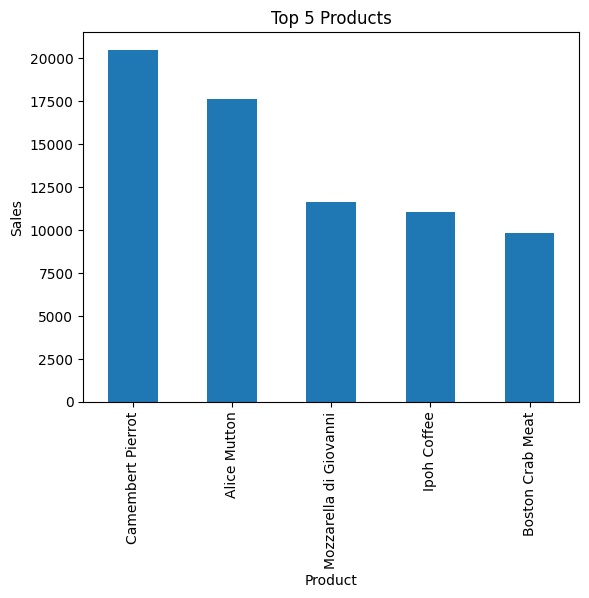

In [37]:
top_products.plot(kind='bar')
plt.title('Top 5 Products')
plt.ylabel('Sales')
plt.show()

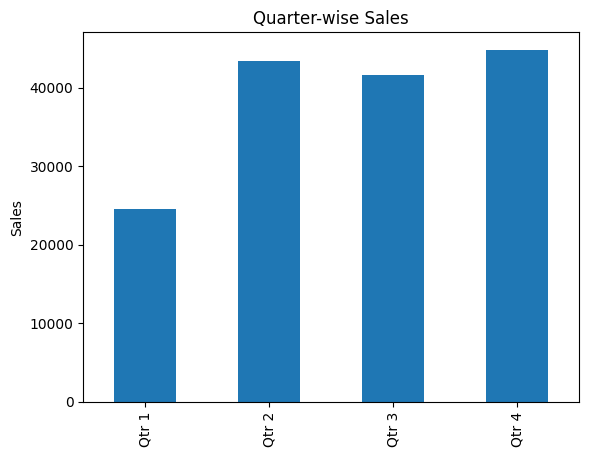

In [38]:
quarter_totals.plot(kind='bar')
plt.title('Quarter-wise Sales')
plt.ylabel('Sales')
plt.show()

In [39]:
top_customers = df.groupby('Customer')['Total Sales'].sum().sort_values(ascending=False).head(5)
print(top_customers)

Customer
QUICK    15481.63
ERNSH    13982.64
SAVEA    13688.45
BERGS     5527.30
MEREP     5362.20
Name: Total Sales, dtype: float64


In [40]:
pivot = df.pivot_table(values='Total Sales', index='Product', columns='Customer', aggfunc='sum', fill_value=0)
print(pivot.head())

Customer                      ALFKI  ANATR  ANTON  AROUT  BERGS  BLAUS  BLONP  \
Product                                                                         
Alice Mutton                    0.0    0.0  702.0    0.0  312.0    0.0    0.0   
Aniseed Syrup                  60.0    0.0    0.0    0.0    0.0    0.0    0.0   
Boston Crab Meat                0.0    0.0  165.6    0.0  920.0    0.0    0.0   
Camembert Pierrot               0.0  340.0    0.0  510.0  680.0    0.0    0.0   
Chef Anton's Cajun Seasoning    0.0    0.0    0.0    0.0  237.6    0.0    0.0   

Customer                       BOLID  BONAP    BOTTM  ...  TRAIH   VAFFE  \
Product                                               ...                  
Alice Mutton                  1170.0    0.0  1170.00  ...    0.0     0.0   
Aniseed Syrup                    0.0    0.0   200.00  ...    0.0   140.0   
Boston Crab Meat                 0.0  772.8   551.25  ...   36.8  1030.0   
Camembert Pierrot                0.0    0.0  1700.00

In [41]:
growth = df[['Qtr 1','Qtr 2','Qtr 3','Qtr 4']].sum().pct_change()*100
print(growth)

Qtr 1          NaN
Qtr 2    76.472591
Qtr 3    -4.130997
Qtr 4     7.594774
dtype: float64


In [42]:
best_qtr = df[['Qtr 1','Qtr 2','Qtr 3','Qtr 4']].sum().idxmax()
print("Best Quarter:", best_qtr)

Best Quarter: Qtr 4
